Kap 3- Övning 13

In [1]:
# Läs in datasetet hr_employee_data.xlsx
import pandas as pd

df = pd.read_excel("hr_employee_data.xlsx")
df.head()


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [2]:
# Visa kolumner, datatyper, antal saknade värden och grundläggande statistik
df.info()
df.describe(include='all')
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 1.3+ MB


Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

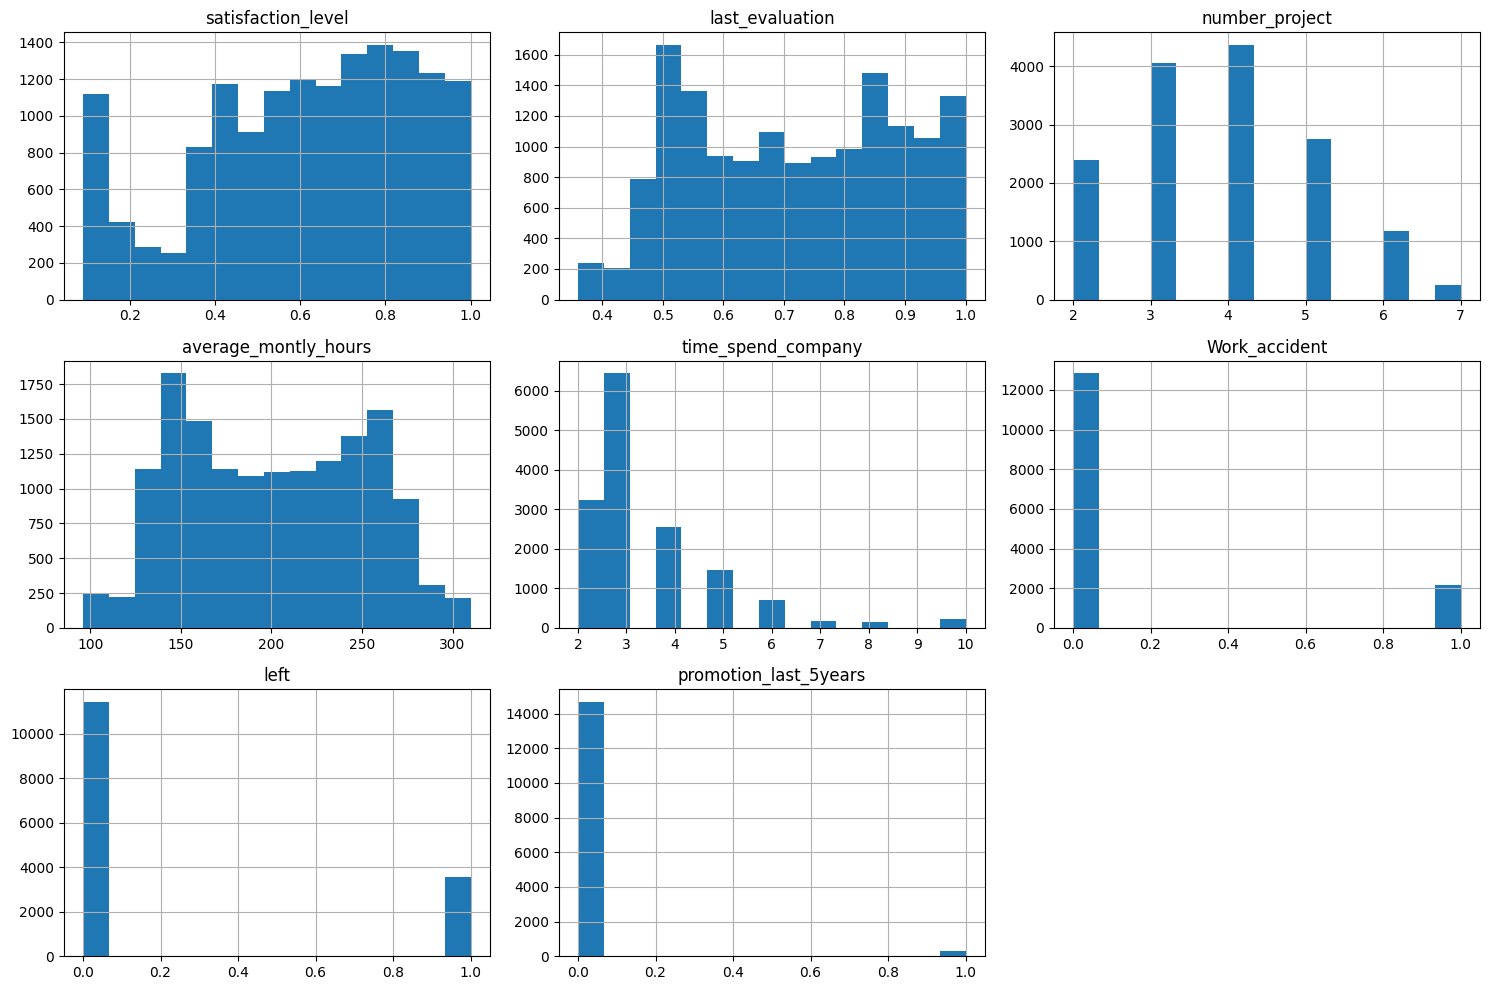

In [3]:
# Visualisera numeriska variabler med histogram
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(bins=15, figsize=(15,10))
plt.tight_layout()
plt.show()

In [4]:
# Räkna värden per kategori för kategoriska kolumner
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"Kolumn: {col}")
    print(df[col].value_counts())
    print("-"*40)

Kolumn: Emp_Id
Emp_Id
IND02438    1
IND28133    1
IND07164    1
IND30478    1
IND24003    1
           ..
IND40221    1
IND24196    1
IND33544    1
IND40533    1
IND11649    1
Name: count, Length: 14999, dtype: int64
----------------------------------------
Kolumn: Department
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64
----------------------------------------
Kolumn: salary
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64
----------------------------------------


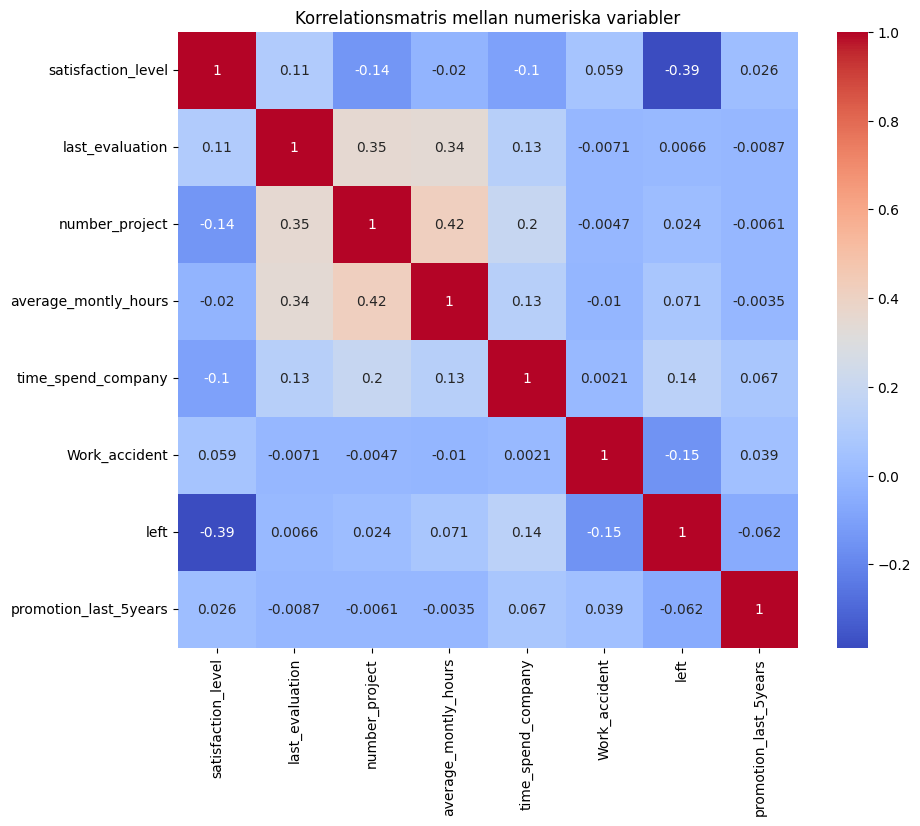

In [5]:

# Korrelationsmatris och värmekarta
import seaborn as sns

corr = df[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Korrelationsmatris mellan numeriska variabler")
plt.show()

In [6]:
# Exempel på insikter
# Medelvärden
if 'Age' in df.columns:
    print(f"Medelålder: {df['Age'].mean():.1f} år")
if 'Salary' in df.columns:
    print(f"Genomsnittlig lön: {df['Salary'].mean():.0f} SEK")

# Antal anställda per avdelning (om kolumnen finns)
if 'Department' in df.columns:
    print("\nAntal anställda per avdelning:")
    print(df['Department'].value_counts())

# Exempel på observationer från korrelation
print("\nExempel på starka korrelationer:")
strong_corr = corr.abs()[corr.abs() > 0.7].stack()
strong_corr = strong_corr[strong_corr < 1]  # ta bort perfekt korrelation med sig själv
print(strong_corr)


Antal anställda per avdelning:
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

Exempel på starka korrelationer:
Series([], dtype: float64)


Analysen av HR-datasetet visar några tydliga mönster. Sales är den största avdelningen, följt av technical och support, vilket tyder på att företaget är starkt fokuserat på dessa områden. Histogrammen visar att arbetsbelastningen varierar mellan anställda, till exempel i antal projekt och arbetade timmar. Korrelationsanalysen visar att det inte finns några starka samband, men att trivsel har en tydlig koppling till personalomsättning – lägre trivsel hänger ihop med att fler slutar. Det finns också ett visst samband mellan antal projekt och arbetade timmar. Sammanfattningsvis visar analysen att trivsel och arbetsbelastning är viktiga faktorer, och att datan kan användas som underlag för beslut kring personal och resursfördelning.

Kap 3- Övning 14

In [18]:
# Läs in diabetes-datasetet och titta på beskrivningen
from sklearn.datasets import load_diabetes

data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [19]:
# Lagra data i X och y
X, y = load_diabetes(return_X_y=True, as_frame=True)

print(X.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: target
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB
None


In [20]:
# Train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Initiera modeller
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42)

In [22]:
# Jämför modeller med cross-validation (ENLIGT BOKEN)
from sklearn.model_selection import cross_validate
import numpy as np

cv = 5

lr_cv = cross_validate(
    lr, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

rf_cv = cross_validate(
    rf, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

In [23]:
# Gör om till positiva RMSE-värden
lr_rmse = -np.mean(lr_cv['test_score'])
rf_rmse = -np.mean(rf_cv['test_score'])

print(f"Linear Regression CV RMSE: {lr_rmse:.2f}")
print(f"Random Forest CV RMSE: {rf_rmse:.2f}")

Linear Regression CV RMSE: 55.97
Random Forest CV RMSE: 58.52


In [24]:
# Välj bästa modell
if rf_rmse < lr_rmse:
    best_model = rf
    print("Random Forest valdes som bästa modell")
else:
    best_model = lr
    print("Linear Regression valdes som bästa modell")

Linear Regression valdes som bästa modell


In [26]:
# Träna bästa modellen på hela träningsdatan
best_model.fit(X_train, y_train)
print("Klar")

Klar


In [27]:
# Slutlig utvärdering på testdata (endast en gång)
from sklearn.metrics import mean_squared_error

y_pred = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test RMSE: {rmse_test:.2f}")

Test RMSE: 53.85


Jag började med att läsa in och utforska diabetesdatasetet. Sedan delade jag upp datan i tränings- och testset. Jag jämförde linjär regression och random forest med cross-validation för att hitta den bästa modellen, som jag sedan tränade på all träningsdata och utvärderade på testsetet med RMSE.

Kap 3- Övning 15


In [28]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [29]:
# Läs in datasetet
df = pd.read_csv("car_price_dataset.csv", sep=";")

In [30]:
# Data cleaning
df = df.dropna()
df.columns = df.columns.str.strip().str.lower()

In [31]:
# Ta bort 'model' för stabilitet
if "model" in df.columns:
    df = df.drop("model", axis=1)

In [32]:
# Dummy encoding av kategoriska variabler
df = pd.get_dummies(df, drop_first=True)

In [33]:
# Features och target
X = df.drop("price", axis=1)
y = df["price"]

In [34]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
# Initiera modeller
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [36]:
# Cross-validation
lr_cv = cross_validate(lr, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
rf_cv = cross_validate(rf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

lr_rmse = -np.mean(lr_cv['test_score'])
rf_rmse = -np.mean(rf_cv['test_score'])

print(f"Linear Regression CV RMSE: {lr_rmse:.2f}")
print(f"Random Forest CV RMSE: {rf_rmse:.2f}")

Linear Regression CV RMSE: 88.87
Random Forest CV RMSE: 570.69


In [37]:
# Välj bästa modell
if rf_rmse < lr_rmse:
    best_model = rf
    print("Random Forest valdes som bästa modell.")
else:
    best_model = lr
    print("Linear Regression valdes som bästa modell.")

Linear Regression valdes som bästa modell.


In [38]:
# Träna på träningsdata och utvärdera
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
final_test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"Slutgiltig RMSE på testdata: {final_test_rmse:.2f}")

Slutgiltig RMSE på testdata: 64.77


In [40]:
# Träna på all data för produktion
best_model.fit(X, y)
print("Modellen tränad på all data")

Modellen tränad på all data


In [41]:
# Spara modell och kolumnordning för Streamlit
joblib.dump(best_model, "car_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")
print("Modellen är nu tränad på all data och sparad!")

Modellen är nu tränad på all data och sparad!


Det jag gjort i uppgiften skulle absolut kunna användas i verkligheten. En modell som denna kan till exempel användas av bilhandlare eller bilsajter för att uppskatta vad en bil är värd utifrån egenskaper som märke, miltal, motorstorlek och årsmodell. Det kan hjälpa både köpare och säljare att få en rimlig prisbild.

Streamlit-appen visar hur det kan fungera i praktiken, där man matar in information om en bil och direkt får ett uppskattat pris. Liknande lösningar finns redan idag på flera bilsajter.

Jag valde att ta bort rader med saknade värden för att förenkla arbetet, men i verkligheten hade man troligen försökt fylla i dessa för att behålla mer data. Samtidigt skulle modellen behöva mer och uppdaterad data för att vara helt pålitlig i en verklig situation.

Kap 3- Övning 16

In [42]:
# ML-flöde för diamonds
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [43]:
# Läs in data
df = pd.read_csv("diamonds.csv")

In [44]:
# Utforska data
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [45]:
# Features och target
X = df.drop("price", axis=1)
y = df["price"]

In [46]:
# Identifiera kategoriska och numeriska kolumner
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [47]:
# Dela upp data i tränings- och testset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
# Preprocessing: OneHotEncoder + passthrough numeriska
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [49]:
# Skapa pipeline med RandomForest
model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42))
])


In [50]:
# Korsvalidering på träningsdata
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_cv = -np.mean(cv_results["test_score"])
print(f"Cross-validation RMSE: {rmse_cv:.2f}")

Cross-validation RMSE: 37.29


In [51]:
# Träna modellen på hela träningsdatan
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [52]:
# Testutvärdering
y_pred = model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse_test:.2f}")

Test RMSE: 23.74


I den här uppgiften har jag byggt ett ML-flöde för att prediktera diamantpriser. Jag började med att läsa in datan och göra en enkel genomgång för att förstå strukturen och se om det fanns saknade värden.

Sedan delade jag upp datan i features och target där pris är det som ska predikteras. Jag separerade kategoriska och numeriska variabler och använde en pipeline med OneHotEncoder för de kategoriska, medan de numeriska fick vara som de är. 

Jag tränade en Random Forest-modell och använde korsvalidering för att få en stabil bild av modellens prestanda. Till sist utvärderade jag modellen på testdatan med RMSE för att se hur bra den fungerar på ny data, osedd data. 

Sammanfattningsvis fungerar modellen bra och pipelinen gör att hela flödet blir smidigt och lätt att använda.